In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import os
np.random.seed(42)

/tmp/ipython-input-789962214.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'time': pd.date_range('2020-01-01', periods=n, freq='H'),


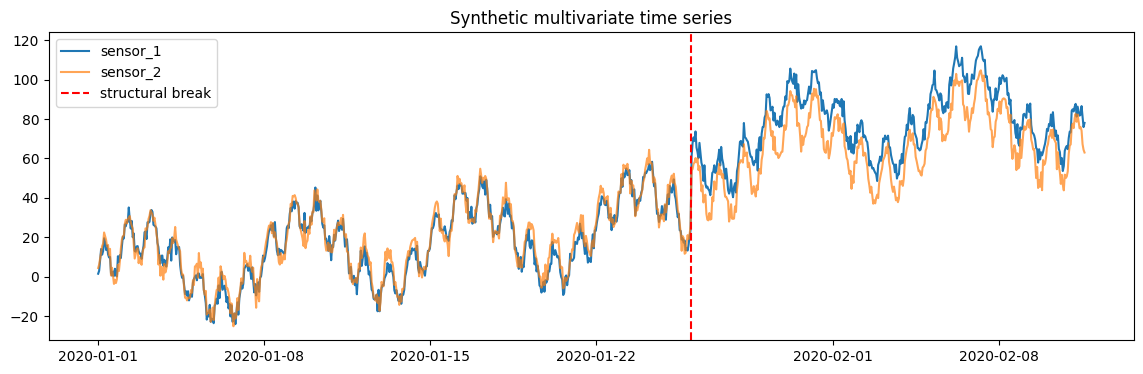

Dataset generated and saved to results/synthetic_multivariate_timeseries.csv


,sensor_1,sensor_2
time,,
2020-02-11 13:00:00,81.186498,67.221126
2020-02-11 14:00:00,75.879643,64.378072
2020-02-11 15:00:00,77.991099,62.975981


In [21]:
#Generate the dataset
#Synthetic multivariate dataset

n = 1000
t = np.arange(n)
break_idx = 600
# seasonal components
daily = 10 * np.sin(2 * np.pi * t / 24)     # daily
weekly = 20 * np.sin(2 * np.pi * t / 168)   # weekly
# trend
trend_base = 0.05 * t
# noise
noise1 = np.random.normal(0, 3, size=n)
noise2 = np.random.normal(0, 5, size=n)
# structural break (level shift after break_idx)
shift = np.where(t > break_idx, 40, 0)

sensor_1 = trend_base + daily + weekly + noise1 + shift
sensor_2 = 0.5 * trend_base + 0.7 * daily + 0.3 * weekly + 0.6 * sensor_1 + noise2*0.5

df = pd.DataFrame({
    'time': pd.date_range('2020-01-01', periods=n, freq='H'),
    'sensor_1': sensor_1,
    'sensor_2': sensor_2
})
df.set_index('time', inplace=True)

# quick plot
plt.figure(figsize=(14,4))
plt.plot(df['sensor_1'], label='sensor_1')
plt.plot(df['sensor_2'], label='sensor_2', alpha=0.7)
plt.axvline(df.index[break_idx], color='red', linestyle='--', label='structural break')
plt.legend(); plt.title("Synthetic multivariate time series"); plt.show()

# save a copy locally in Colab
os.makedirs("results", exist_ok=True)
df.to_csv("results/synthetic_multivariate_timeseries.csv")
print("Dataset generated and saved to results/synthetic_multivariate_timeseries.csv")
df.tail(3)



In [22]:
# Helper: build transition (F) and observation (H) matrices
# ---------------------------
def build_ssm_matrices(p1=24, p2=48):
    """
    Build state-space matrices for one series:
    state vector = [level, trend, seasonal1 (p1-1 dims), seasonal2 (p2-1 dims)]
    """
    m1 = p1 - 1
    m2 = p2 - 1
    n_state = 2 + m1 + m2
    F = np.zeros((n_state, n_state))

    # level & trend
    F[0,0] = 1.0
    F[0,1] = 1.0   # level(t+1) = level(t) + trend(t)
    F[1,1] = 1.0   # trend random walk

    # seasonal1 companion form
    if m1 > 0:
        for i in range(m1-1):
            F[2+i, 2+i+1] = 1.0
        F[2+m1-1, 2:2+m1] = -1.0

    # seasonal2 companion form
    offset = 2 + m1
    if m2 > 0:
        for i in range(m2-1):
            F[offset+i, offset+i+1] = 1.0
        F[offset+m2-1, offset:offset+m2] = -1.0

    # observation: we observe level + first seasonal element of each block
    H = np.zeros((1, n_state))
    H[0,0] = 1.0
    if m1 > 0:
        H[0,2] = 1.0
    if m2 > 0:
        H[0,offset] = 1.0

    return F, H, n_state
# quick check
F_test, H_test, nstate_test = build_ssm_matrices(p1=24, p2=48)
print("State size example:", nstate_test)

State size example: 72


In [23]:
#Kalman Filter and RTS Smoother
def kalman_filter(y, F, H, Q, R, x0=None, P0=None):
    T = len(y)
    n = F.shape[0]
    # init
    x_prev = np.zeros(n) if x0 is None else x0.copy()
    P_prev = np.eye(n) if P0 is None else P0.copy()

    x_pred = np.zeros((T, n)); P_pred = np.zeros((T, n, n))
    x_filt = np.zeros((T, n)); P_filt = np.zeros((T, n, n))

    for t in range(T):
        # predict
        x_pr = F @ x_prev
        P_pr = F @ P_prev @ F.T + Q
        # update
        y_t = y[t]
        S = (H @ P_pr @ H.T) + R  # scalar
        K = (P_pr @ H.T) / S      # n x 1
        resid = y_t - (H @ x_pr)
        x_up = x_pr + (K.flatten() * resid)
        P_up = P_pr - (K @ H) @ P_pr
        # store
        x_pred[t] = x_pr; P_pred[t] = P_pr
        x_filt[t] = x_up; P_filt[t] = P_up
        x_prev = x_up; P_prev = P_up
    return x_pred, P_pred, x_filt, P_filt

def rts_smoother(x_pred, P_pred, x_filt, P_filt, F):
    T, n = x_filt.shape
    x_smooth = np.zeros_like(x_filt); P_smooth = np.zeros_like(P_filt)
    x_smooth[-1] = x_filt[-1]; P_smooth[-1] = P_filt[-1]
    for t in range(T-2, -1, -1):
        P_pr_next = P_pred[t+1]
        # safe inversion
        invPpr = np.linalg.pinv(P_pr_next)
        A = P_filt[t] @ F.T @ invPpr
        x_smooth[t] = x_filt[t] + A @ (x_smooth[t+1] - x_pred[t+1])
        P_smooth[t] = P_filt[t] + A @ (P_smooth[t+1] - P_pr_next) @ A.T
    return x_smooth, P_smooth

In [24]:
#Prepare training/test split
# Train/test split
horizon = 200
train_df = df.iloc[:-horizon].copy()
test_df = df.iloc[-horizon:].copy()
print("Train shape:", train_df.shape, "Test shape:", test_df.shape)

Train shape: (800, 2) Test shape: (200, 2)


In [26]:
#Run SSM + KF + smoothing & forecast for one series
# Run SSM for one series, produce forecast of length horizon
# ---------------------------
def run_ssm_single(series_full, p1=24, p2=48, Q_scale=1.0, R_scale=1.0, forecast_horizon=200):
    # series_full: pd.Series covering train+test (we use whole to run filter then forecast)
    y_full = series_full.values
    F, H, n_state = build_ssm_matrices(p1=p1, p2=p2)
    # base Q (small noises)
    Q_base = np.zeros((n_state, n_state))
    Q_base[0,0] = 1e-4
    Q_base[1,1] = 1e-5
    for i in range(2, n_state):
        Q_base[i,i] = 1e-6
    Q = Q_base * Q_scale
    # estimate measurement variance R from in-sample residual variance (quick proxy)
    # residual = series - rolling mean (seasonal approx)
    resid_est = series_full - series_full.rolling(window=24, min_periods=1).mean()
    rvar = np.nanvar(resid_est.dropna())
    if rvar <= 0: rvar = 1.0
    R = np.array([[rvar * R_scale]])
    x0 = np.zeros(n_state); P0 = np.eye(n_state) * 1.0

    # run filter across the entire available (train+test) to get smoothed last state
    x_pred, P_pred, x_filt, P_filt = kalman_filter(y_full, F, H, Q, R, x0=x0, P0=P0)
    x_smooth, P_smooth = rts_smoother(x_pred, P_pred, x_filt, P_filt, F)

    # forecast from last smoothed state
    last_state = x_smooth[-1].copy()
    last_P = P_smooth[-1].copy()
    forecasts = []
    state = last_state.copy(); Pstate = last_P.copy()
    for h in range(forecast_horizon):
        state = F @ state
        Pstate = F @ Pstate @ F.T + Q
        ypred = (H @ state).item()
        forecasts.append(ypred)
    return np.array(forecasts), x_smooth, P_smooth, Q, R

In [27]:
#Sensitivity analysis loop across Q & R multipliers
# Sensitivity analysis grid
# ---------------------------
Q_multipliers = [0.1, 1.0, 5.0, 10.0]
R_multipliers = [0.1, 1.0, 5.0, 10.0]

results = []
for Qm in Q_multipliers:
    for Rm in R_multipliers:
        rmse_list = []; mae_list = []
        forecasts_all = pd.DataFrame(index=test_df.index)
        for col in train_df.columns:
            # build series covering train+test for filtering (we use full df so filter sees entire range)
            series_full = pd.concat([train_df[col], test_df[col]])
            fc, x_smooth, P_smooth, Q_used, R_used = run_ssm_single(series_full, p1=24, p2=48,
                                                                     Q_scale=Qm, R_scale=Rm, forecast_horizon=horizon)
            actual = test_df[col].values
            rmse_list.append(np.sqrt(mean_squared_error(actual, fc)))
            mae_list.append(mean_absolute_error(actual, fc))
            forecasts_all[col] = fc
        results.append({'Qm':Qm,'Rm':Rm,'rmse_mean':np.mean(rmse_list),'mae_mean':np.mean(mae_list),'forecasts':forecasts_all})
        print(f"Qm={Qm}, Rm={Rm} -> RMSE={np.mean(rmse_list):.4f}, MAE={np.mean(mae_list):.4f}")
# find best setting
best = min(results, key=lambda r: r['rmse_mean'])
print("Best config found:", best['Qm'], best['Rm'], "RMSE:", best['rmse_mean'])

Qm=0.1, Rm=0.1 -> RMSE=25.2754, MAE=21.1636
Qm=0.1, Rm=1.0 -> RMSE=17.6240, MAE=14.5021
Qm=0.1, Rm=5.0 -> RMSE=23.9516, MAE=19.8936
Qm=0.1, Rm=10.0 -> RMSE=25.8705, MAE=21.6162
Qm=1.0, Rm=0.1 -> RMSE=36.7769, MAE=32.2579
Qm=1.0, Rm=1.0 -> RMSE=23.1883, MAE=19.5996
Qm=1.0, Rm=5.0 -> RMSE=16.4351, MAE=13.5752
Qm=1.0, Rm=10.0 -> RMSE=16.9434, MAE=14.1012
Qm=5.0, Rm=0.1 -> RMSE=20.1988, MAE=16.5787
Qm=5.0, Rm=1.0 -> RMSE=33.3373, MAE=29.4988
Qm=5.0, Rm=5.0 -> RMSE=22.3577, MAE=18.9584
Qm=5.0, Rm=10.0 -> RMSE=18.8489, MAE=15.6470
Qm=10.0, Rm=0.1 -> RMSE=23.2469, MAE=19.0725
Qm=10.0, Rm=1.0 -> RMSE=33.9303, MAE=30.0698
Qm=10.0, Rm=5.0 -> RMSE=26.7157, MAE=23.2238
Qm=10.0, Rm=10.0 -> RMSE=22.2230, MAE=18.8482
Best config found: 1.0 5.0 RMSE: 16.43508938217801


In [28]:
#Baseline: Exponential Smoothing (Holt-Winters) per series
# Baseline per-series Exponential Smoothing
# ---------------------------
def baseline_exp(train, test, seasonal_periods=24):
    fc_df = pd.DataFrame(index=test.index)
    rmse_list = []; mae_list = []
    for col in train.columns:
        try:
            model = ExponentialSmoothing(train[col], seasonal_periods=seasonal_periods, trend='add', seasonal='add', initialization_method='estimated')
            fit = model.fit(optimized=True, use_brute=True)
            fc = fit.forecast(len(test))
        except Exception as e:
            # fallback: simple naive last value
            fc = pd.Series(np.repeat(train[col].iloc[-1], len(test)), index=test.index)
        fc_df[col] = fc.values
        rmse_list.append(np.sqrt(mean_squared_error(test[col].values, fc.values)))
        mae_list.append(mean_absolute_error(test[col].values, fc.values))
    return fc_df, np.mean(rmse_list), np.mean(mae_list)

baseline_fc, base_rmse, base_mae = baseline_exp(train_df, test_df, seasonal_periods=24)
print("Baseline Exponential Smoothing mean RMSE:", base_rmse, "MAE:", base_mae)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Baseline Exponential Smoothing mean RMSE: 43.517504681688806 MAE: 40.12225940116164


sensor_1 {'ssm_rmse': np.float64(16.65624661220608), 'ssm_mae': 13.828258906339224, 'baseline_rmse': np.float64(54.059653500623135), 'baseline_mae': 50.14116940225367}
sensor_2 {'ssm_rmse': np.float64(16.21393215214994), 'ssm_mae': 13.322067546444927, 'baseline_rmse': np.float64(32.97535586275448), 'baseline_mae': 30.103349400069618}
SSM (best) mean RMSE: 16.43508938217801 MAE: 13.575163226392075
Baseline mean RMSE: 43.517504681688806 MAE: 40.12225940116164


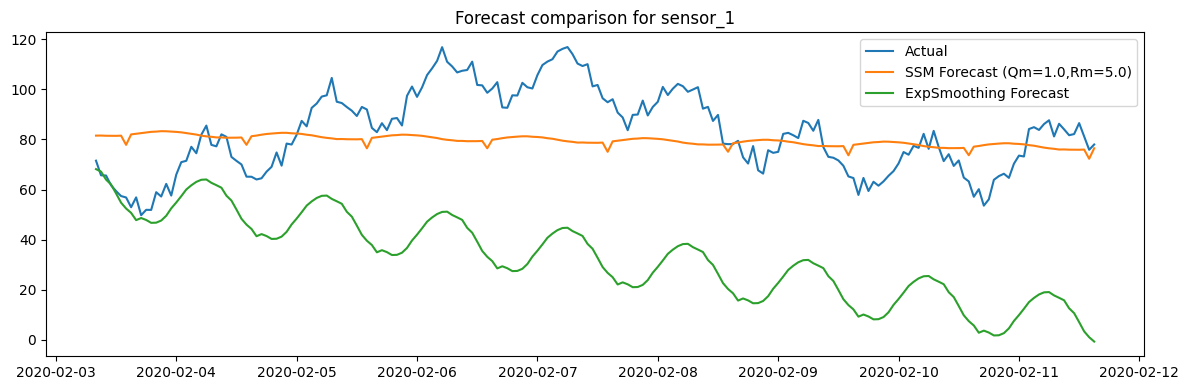

Saved results in results/summary_metrics.csv and results/forecast_comparison.png


In [30]:
#Compare best SSM to baseline, save plots & metrics
# Compare & save

best_forecasts = best['forecasts']
# compute metrics per series
metrics = {}
for col in df.columns:
    ssm_fc = best_forecasts[col].values
    actual = df[col].values[-horizon:]
    metrics[col] = {
        'ssm_rmse': np.sqrt(mean_squared_error(actual, ssm_fc)),
        'ssm_mae': mean_absolute_error(actual, ssm_fc),
        'baseline_rmse': np.sqrt(mean_squared_error(actual, baseline_fc[col].values)),
        'baseline_mae': mean_absolute_error(actual, baseline_fc[col].values)
    }
    print(col, metrics[col])

ssm_rmse_mean = np.mean([metrics[c]['ssm_rmse'] for c in metrics])
ssm_mae_mean  = np.mean([metrics[c]['ssm_mae'] for c in metrics])
print("SSM (best) mean RMSE:", ssm_rmse_mean, "MAE:", ssm_mae_mean)
print("Baseline mean RMSE:", base_rmse, "MAE:", base_mae)

# plot example series comparison
series_to_plot = df.columns[0]
plt.figure(figsize=(12,4))
plt.plot(df.index[-horizon:], df[series_to_plot].values[-horizon:], label='Actual')
plt.plot(df.index[-horizon:], best_forecasts[series_to_plot].values, label=f'SSM Forecast (Qm={best["Qm"]},Rm={best["Rm"]})')
plt.plot(df.index[-horizon:], baseline_fc[series_to_plot].values, label='ExpSmoothing Forecast')
plt.title(f"Forecast comparison for {series_to_plot}")
plt.legend(); plt.tight_layout()
plt.savefig("results/forecast_comparison.png", dpi=150)
plt.show()

# save summary
summary = {
    'best_Qm': best['Qm'], 'best_Rm': best['Rm'],
    'ssm_rmse_mean': ssm_rmse_mean, 'ssm_mae_mean': ssm_mae_mean,
    'baseline_rmse_mean': base_rmse, 'baseline_mae_mean': base_mae
}
pd.DataFrame([summary]).to_csv("results/summary_metrics.csv", index=False)
print("Saved results in results/summary_metrics.csv and results/forecast_comparison.png")